# Fracture MMS hard-curl PINN — Nonconforming opposite-diagonal triangular mesh — Options A and B

This notebook reconstructs the bulk Darcy flux for the single-fracture MMS on
\(\Gamma=\{(t,t):0\le t\le1\}\). The mesh-specific block below is ported from
`LCG_Deng_flux_reconstruction_MMS_nonconforming_opposite_diagonal_P0.ipynb`. The reconstruction itself is imported from
`fracture_hardcurl_common.py` and is mesh-independent: it sees points and oriented
dual-face segments, never elements.

## Fixed conventions

- The fracture is oriented from \(A=(0,0)\) to \(B=(1,1)\), with
  \(\tau=(1,1)/\sqrt2\) and one fixed normal
  \(n_\Gamma=(-1,1)/\sqrt2\), pointing to \(\Omega^+=\{y>x\}\).
- Everywhere,
  \([[q\cdot n_\Gamma]]=q^+\cdot n_\Gamma-q^-\cdot n_\Gamma=\lambda\).
- The bulk balance audited on every dual CV is
  \(\oint_{\partial\omega}q\cdot n\,ds-\int_\omega f_m\,dx
  -\int_{\Gamma\cap\omega}\lambda\,ds=0\).
- Both exact-\(\lambda\) and discrete-\(\lambda_h\) right-hand sides are reported.
- `float64` and fixed seeds are used throughout. Every construction gate prints its
  tolerance and raises immediately on failure.
- The `source` CV class is retained in the common audit schema but is empty/N/A for
  this smooth distributed MMS source; \(\int_\omega f_m\) is still evaluated on
  every CV.
- Because the fracture is corner-to-corner, there is no artificial interface
  extension. Option B reports its extension-continuity penalty explicitly as N/A.

The conforming solve uses the established independent coarse P0 multiplier mesh
with \(h_\lambda=2h\); this is the multiplier used by \(q_{p,\lambda}\).


## 1. Mesh-specific MMS and CG–LMDFM block

Ported without modifying the source notebook.

In [1]:
# ============================================================
# Configuration and imports
# ============================================================
from mpi4py import MPI
import numpy as np
import math
import time
import pathlib
import importlib.util
import basix
import matplotlib.pyplot as plt
from tqdm import tqdm

from dolfinx import mesh, fem, geometry
from dolfinx.fem import petsc
from petsc4py import PETSc
try:
    from dolfinx.io import gmsh as gmshio
except ImportError:
    from dolfinx.io import gmshio
import ufl

# Matrix/fracture pressure order.  The multiplier is DG0/P0 by default.
order = 1
lambda_order = 0
Gamma_tag = 2  # kept for compatibility; the opposite-diagonal mesh has no Gamma facets.

# Independent 1D mesh sizes. The fracture pressure mesh uses h_gamma ~= h/2,
# while the P0 multiplier is coarser to avoid the nonconforming inf-sup trouble.
FRACTURE_PRESSURE_LC_FACTOR = 0.5
LAMBDA_COARSEN = 3.0
MULTIPLIER_LC_FACTOR = LAMBDA_COARSEN

# Meshes are created on demand only when the .msh file is missing.
BULK_MESH_BASENAME = "regular_tri_opposite_diagonal"
CREATE_MISSING_MESHES = True
MESH_GENERATOR_NAME = "generate_regular_tri_opposite_diagonal_meshes.py"

# Section 0: convergence analysis. Keep False for a quick diagnostic run.
RUN_CONVERGENCE = False
CONV_REFS = [2, 3, 4, 5, 6, 7]

CASES = [
    {"name": "order1_P0", "order": 1, "lambda_order": 0},
    {"name": "order2_P0", "order": 2, "lambda_order": 0},
    {"name": "order2_P1", "order": 2, "lambda_order": 1}
]
RESULTS_DIR = pathlib.Path("deng_convergence_results/nonconforming_opposite_diagonal")

# Main comparison run.
REF_DEMO = 6

# Jump/error summaries exclude the tip layer below.
TIP_FRAC = 0.10

# Residual-map color range. Values outside this range are saturated.
RK_LOG_VMIN = -10.0
RK_LOG_VMAX = -1.0
RK_CBAR_TICKS = np.arange(RK_LOG_VMIN, RK_LOG_VMAX + 1, 1, dtype=float)

Lx, Ly = 1.0, 1.0
x_start, x_end = 0.0, 1.0
y_start, y_end = 0.0, 1.0
FRAC_A = np.array([x_start, y_start], dtype=float)
FRAC_B = np.array([x_end, y_end], dtype=float)
ALPHA = 1.0
K_M_VALUE = 1.0
K_F_VALUE = 100.0

comm = MPI.COMM_SELF
rank = comm.rank

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


In [2]:
# ============================================================
# MMS data and idempotent opposite-diagonal mesh lookup
# ============================================================
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm


tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))


def _fracture_problem_dirs():
    here = pathlib.Path.cwd()
    return [
        here,
        here / "fenicsx/code/fracture problem",
        pathlib.Path("fenicsx/code/fracture problem"),
        pathlib.Path(__file__).resolve().parent if "__file__" in globals() else here,
    ]


def _find_fracture_problem_file(name):
    tried = []
    for root in _fracture_problem_dirs():
        p = root / name
        tried.append(str(p))
        if p.exists():
            return p.resolve()
    return None


def mesh_path_for_ref(ref):
    name = f"{BULK_MESH_BASENAME}_{int(ref)}.msh"
    found = _find_fracture_problem_file(name)
    if found is not None:
        return str(found)
    if not CREATE_MISSING_MESHES:
        raise FileNotFoundError(f"Could not find {name} and CREATE_MISSING_MESHES=False")

    script = _find_fracture_problem_file(MESH_GENERATOR_NAME)
    if script is None:
        raise FileNotFoundError(f"Could not find {MESH_GENERATOR_NAME}; cannot create {name}")
    spec = importlib.util.spec_from_file_location("regular_tri_opposite_meshgen", script)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    target = mod.generate_mesh(int(ref), script.parent, overwrite=False)
    return str(pathlib.Path(target).resolve())


def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]


def signed_distance_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A[None, :]) @ normal_np


def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A[None, :]) @ tau_np


def q_exact_xy(x0, y0):
    return np.sin(np.pi * x0) * np.sin(np.pi * y0)


def r_exact_xy(x0, y0):
    return normal_np[0] * (x0 - FRAC_A[0]) + normal_np[1] * (y0 - FRAC_A[1])


def p_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    return q + ALPHA * np.abs(r_exact_xy(x0, y0)) * q


def p_gamma_exact_xy(x0, y0):
    return q_exact_xy(x0, y0)


def lambda_exact_xy(x0, y0):
    return -2.0 * ALPHA * q_exact_xy(x0, y0)


def p_m_exact_fn(x):
    return p_m_exact_xy(x[0], x[1])


def p_f_exact_fn(t):
    return np.sin(np.pi * t) ** 2


def lam_exact_fn(t):
    return -2.0 * ALPHA * np.sin(np.pi * t) ** 2


def grad_q_exact_xy(x0, y0):
    return np.column_stack([
        np.pi * np.cos(np.pi * x0) * np.sin(np.pi * y0),
        np.pi * np.sin(np.pi * x0) * np.cos(np.pi * y0),
    ])


def exact_grad_p(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    q = q_exact_xy(x, y)
    grad_q = grad_q_exact_xy(x, y)
    r = r_exact_xy(x, y)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    return grad_q + ALPHA * (
        sign_r[:, None] * normal_np[None, :] * q[:, None]
        + np.abs(r)[:, None] * grad_q
    )


def exact_q(points):
    return -K_M_VALUE * exact_grad_p(points)


def exact_dp_gamma_ds(s):
    pts = real_points_np(s)
    grad_q = grad_q_exact_xy(pts[:, 0], pts[:, 1])
    return grad_q @ tau_np


def f_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    r = r_exact_xy(x0, y0)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    n_dot_grad_q = (
        normal_np[0] * np.pi * np.cos(np.pi * x0) * np.sin(np.pi * y0)
        + normal_np[1] * np.pi * np.sin(np.pi * x0) * np.cos(np.pi * y0)
    )
    return K_M_VALUE * (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * np.abs(r) * q
        - 2.0 * ALPHA * sign_r * n_dot_grad_q
    )


def f_m_exact_points(points):
    points = np.asarray(points, dtype=float)
    return f_m_exact_xy(points[:, 0], points[:, 1])


def f_callable(x):
    return f_m_exact_xy(x[0], x[1])


def f_gamma_exact_xy(x0, y0):
    qg = q_exact_xy(x0, y0)
    d2_q_ds2 = (
        -np.pi**2 * qg
        + 2.0 * np.pi**2 * tau_np[0] * tau_np[1]
        * np.cos(np.pi * x0) * np.cos(np.pi * y0)
    )
    return -K_F_VALUE * d2_q_ds2 + lambda_exact_xy(x0, y0)


def ff_callable(x):
    return f_gamma_exact_xy(x[0], x[1])


def k_callable(x):
    return (x[0] * 0.0 + K_M_VALUE)[np.newaxis, :]


In [3]:
# ============================================================
# Nonconforming LCG solve on opposite-diagonal triangular bulk meshes
# ============================================================
def gauss_interval(n):
    x, w = np.polynomial.legendre.leggauss(int(n))
    return 0.5 * (x + 1.0), 0.5 * w


_GL, _WL = gauss_interval(12)


def _space_ndofs(V):
    return int(V.dofmap.index_map.size_local * V.dofmap.index_map_bs)


def estimate_bulk_h(omega):
    coords = omega.geometry.x[:, :2]

    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf

    return min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))


def make_line_mesh_from_s_nodes(s_nodes):
    s_nodes = np.asarray(s_nodes, dtype=float)
    nodes = real_points_np(s_nodes)
    n_cells = len(s_nodes) - 1
    cells = np.column_stack([np.arange(n_cells), np.arange(1, n_cells + 1)]).astype(np.int64)
    coord_el = ufl.Mesh(basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(2,)))
    try:
        gamma_mesh = mesh.create_mesh(comm, cells, coord_el, nodes)
    except (TypeError, AttributeError, IndexError):
        gamma_mesh = mesh.create_mesh(comm, cells, nodes, coord_el)
    return gamma_mesh, float(np.max(np.diff(s_nodes))), int(n_cells), s_nodes


def make_fracture_meshes(h):
    h_gamma_target = FRACTURE_PRESSURE_LC_FACTOR * h
    h_lambda_target = MULTIPLIER_LC_FACTOR * h
    n_gamma = max(1, int(np.ceil(L_gamma / h_gamma_target)))
    n_lambda = max(1, int(np.ceil(L_gamma / h_lambda_target)))
    s_gamma = np.linspace(0.0, L_gamma, n_gamma + 1)
    s_lambda = np.linspace(0.0, L_gamma, n_lambda + 1)
    gamma, h_gamma, n_gamma, _ = make_line_mesh_from_s_nodes(s_gamma)
    gamma_l, h_lambda, n_lambda, _ = make_line_mesh_from_s_nodes(s_lambda)
    return gamma, gamma_l, h_gamma, h_lambda, n_gamma, n_lambda, s_gamma, s_lambda


def build_bulk_trace_data(omega, V_m):
    tdim = omega.topology.dim
    fdim = tdim - 1
    for pair in [(tdim, 0), (fdim, 0), (tdim, fdim)]:
        omega.topology.create_connectivity(*pair)
    c2v = omega.topology.connectivity(tdim, 0)
    geom = omega.geometry.x[:, :2]
    elem = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    dofmap = V_m.dofmap
    cells = []
    for ci in range(omega.topology.index_map(tdim).size_local):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        cells.append({
            "cell_id": int(ci),
            "verts": verts,
            "coords": coords,
            "J": J,
            "invJ": np.linalg.inv(J),
            "dofs": np.asarray(dofmap.cell_dofs(ci), dtype=np.int32),
            "elem": elem,
        })
    tree = geometry.bb_tree(omega, tdim)
    return {"omega": omega, "cells": cells, "tree": tree, "elem": elem}


def locate_bulk_cell_xy(pt, bulk_trace, tol=1.0e-12):
    omega = bulk_trace["omega"]
    pts3 = np.zeros((1, 3), dtype=float)
    pts3[0, :2] = np.asarray(pt, dtype=float)[:2]
    candidates = geometry.compute_collisions_points(bulk_trace["tree"], pts3)
    colliding = geometry.compute_colliding_cells(omega, candidates, pts3)
    links = colliding.links(0)
    if len(links):
        return bulk_trace["cells"][int(links[0])]
    for shift in [tol * normal_np, -tol * normal_np, tol * tau_np, -tol * tau_np]:
        pts3[0, :2] = np.asarray(pt, dtype=float)[:2] + shift
        candidates = geometry.compute_collisions_points(bulk_trace["tree"], pts3)
        colliding = geometry.compute_colliding_cells(omega, candidates, pts3)
        links = colliding.links(0)
        if len(links):
            return bulk_trace["cells"][int(links[0])]
    raise RuntimeError(f"Could not locate bulk triangle containing point {pt}")


def triangle_values_grads_on_cell(cell, points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xi = (pts - cell["coords"][0]) @ cell["invJ"].T
    tab = _tab(cell["elem"], 1, xi)
    vals = tab[0]
    ref_grads = np.stack([tab[1], tab[2]], axis=2)
    grads = ref_grads @ cell["invJ"]
    return vals, grads


def fracture_breakpoints_from_bulk_mesh(omega, tol=1.0e-12):
    tdim = omega.topology.dim
    fdim = tdim - 1
    omega.topology.create_connectivity(fdim, 0)
    f2v = omega.topology.connectivity(fdim, 0)
    geom = omega.geometry.x[:, :2]
    s_vals = [0.0, L_gamma]
    for fi in range(omega.topology.index_map(fdim).size_local):
        verts = np.asarray(f2v.links(fi), dtype=np.int32)
        if len(verts) != 2:
            continue
        s_int = segment_edge_s_intersection(geom[int(verts[0])], geom[int(verts[1])], tol=tol)
        if s_int is not None:
            s_vals.append(float(s_int))
    s_vals = np.array(sorted(s_vals), dtype=float)
    unique = []
    for s in s_vals:
        if not unique or abs(s - unique[-1]) > 1.0e-11:
            unique.append(float(np.clip(s, 0.0, L_gamma)))
    return np.asarray(unique, dtype=float)


def s_breakpoints(s0, s1, s_nodes, tol=1.0e-12):
    s0 = float(s0); s1 = float(s1)
    if s1 < s0:
        s0, s1 = s1, s0
    inside = np.asarray(s_nodes, dtype=float)
    inside = inside[(inside > s0 + tol) & (inside < s1 - tol)]
    return np.concatenate(([s0], np.unique(np.round(inside, 14)), [s1])).astype(float)


def lagrange_1d_values_and_derivatives(nodes, x):
    nodes = np.asarray(nodes, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    n = len(nodes)
    vals = np.ones((x.size, n), dtype=float)
    ders = np.zeros((x.size, n), dtype=float)
    if n == 1:
        return vals, ders
    for i in range(n):
        for j in range(n):
            if j != i:
                vals[:, i] *= (x - nodes[j]) / (nodes[i] - nodes[j])
        for k in range(n):
            if k == i:
                continue
            term = np.ones_like(x) / (nodes[i] - nodes[k])
            for j in range(n):
                if j != i and j != k:
                    term *= (x - nodes[j]) / (nodes[i] - nodes[j])
            ders[:, i] += term
    return vals, ders


def build_line_space_data(domain, V):
    domain.topology.create_connectivity(domain.topology.dim, 0)
    c2v = domain.topology.connectivity(domain.topology.dim, 0)
    geom_s = s_coord_np(domain.geometry.x[:, :2])
    dof_coords = V.tabulate_dof_coordinates()[:, :2]
    dof_s_all = s_coord_np(dof_coords)
    cells = []
    s_nodes = []
    for ci in range(domain.topology.index_map(domain.topology.dim).size_local):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        s0, s1 = np.sort(geom_s[verts])
        dofs = np.asarray(V.dofmap.cell_dofs(ci), dtype=np.int32)
        dof_s = dof_s_all[dofs]
        ell = float(s1 - s0)
        if ell <= 0.0:
            continue
        nodes = np.unique(np.round((dof_s - s0) / ell, 14))
        dof_node_idx = np.searchsorted(nodes, np.round((dof_s - s0) / ell, 14))
        cells.append({
            "cell_id": int(ci),
            "dofs": dofs,
            "s0": float(s0),
            "s1": float(s1),
            "ell": ell,
            "nodes": nodes,
            "dof_node_idx": dof_node_idx,
        })
        s_nodes.extend([float(s0), float(s1)])
    s_nodes = np.array(sorted(set(np.round(s_nodes, 14))), dtype=float)
    cells = [cells[i] for i in np.argsort([c["s0"] for c in cells])]
    return {"cells": cells, "s_nodes": s_nodes}


def locate_line_cell_s(s, line_data, tol=1.0e-12):
    cells = line_data["cells"]
    if s <= cells[0]["s0"] + tol:
        return cells[0]
    if s >= cells[-1]["s1"] - tol:
        return cells[-1]
    starts = np.array([c["s0"] for c in cells], dtype=float)
    idx = int(np.searchsorted(starts, s, side="right") - 1)
    return cells[min(max(idx, 0), len(cells) - 1)]


def line_values_derivatives_on_cell(cell, s):
    s = np.asarray(s, dtype=float).reshape(-1)
    xi = (s - cell["s0"]) / cell["ell"]
    L, dL = lagrange_1d_values_and_derivatives(cell["nodes"], xi)
    nd = len(cell["dofs"])
    vals = np.zeros((s.size, nd), dtype=float)
    ders = np.zeros((s.size, nd), dtype=float)
    for a in range(nd):
        ia = cell["dof_node_idx"][a]
        vals[:, a] = L[:, ia]
        ders[:, a] = dL[:, ia] / cell["ell"]
    return vals, ders


def assemble_fracture_and_trace_blocks(A, b, gamma, gamma_l, V_f, V_l, bulk_trace, offsets, bulk_s_nodes):
    off_m, off_f, off_l = offsets
    pressure_data = build_line_space_data(gamma, V_f)
    multiplier_data = build_line_space_data(gamma_l, V_l)

    # Fracture pressure equation: int K_f dp_f/ds dpsi/ds + int lambda psi = int f_f psi.
    for cell in pressure_data["cells"]:
        fdofs = cell["dofs"].astype(np.int32)
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi, dpsi = line_values_derivatives_on_cell(cell, s_q)
        weight = cell["ell"] * _WL
        Kloc = K_F_VALUE * np.einsum("q,qi,qj->ij", weight, dpsi, dpsi)
        floc = np.einsum("q,q,qi->i", weight, f_gamma_exact_xy(x_q[:, 0], x_q[:, 1]), psi)
        A.setValues(off_f + fdofs, off_f + fdofs, Kloc, addv=PETSc.InsertMode.ADD_VALUES)
        b.setValues(off_f + fdofs, floc, addv=PETSc.InsertMode.ADD_VALUES)

    for lcell in multiplier_data["cells"]:
        ldofs = lcell["dofs"].astype(np.int32)
        s0, s1 = lcell["s0"], lcell["s1"]

        pbreaks = s_breakpoints(s0, s1, pressure_data["s_nodes"])
        for a, c in zip(pbreaks[:-1], pbreaks[1:]):
            if c - a <= 1.0e-14:
                continue
            pcell = locate_line_cell_s(0.5 * (a + c), pressure_data)
            fdofs = pcell["dofs"].astype(np.int32)
            s_q = a + (c - a) * _GL
            psi = line_values_derivatives_on_cell(pcell, s_q)[0]
            mu = line_values_derivatives_on_cell(lcell, s_q)[0]
            weight = (c - a) * _WL
            A.setValues(off_f + fdofs, off_l + ldofs, np.einsum("q,qi,qj->ij", weight, psi, mu), addv=PETSc.InsertMode.ADD_VALUES)
            A.setValues(off_l + ldofs, off_f + fdofs, -np.einsum("q,qi,qj->ij", weight, mu, psi), addv=PETSc.InsertMode.ADD_VALUES)

        bbreaks = s_breakpoints(s0, s1, bulk_s_nodes)
        for a, c in zip(bbreaks[:-1], bbreaks[1:]):
            if c - a <= 1.0e-14:
                continue
            s_mid = 0.5 * (a + c)
            bulk_cell = locate_bulk_cell_xy(real_points_np([s_mid])[0], bulk_trace)
            mdofs = bulk_cell["dofs"].astype(np.int32)
            s_q = a + (c - a) * _GL
            x_q = real_points_np(s_q)
            phi = triangle_values_grads_on_cell(bulk_cell, x_q)[0]
            mu = line_values_derivatives_on_cell(lcell, s_q)[0]
            weight = (c - a) * _WL
            A.setValues(mdofs, off_l + ldofs, -np.einsum("q,qi,qj->ij", weight, phi, mu), addv=PETSc.InsertMode.ADD_VALUES)
            A.setValues(off_l + ldofs, mdofs, np.einsum("q,qi,qj->ij", weight, mu, phi), addv=PETSc.InsertMode.ADD_VALUES)


def apply_pressure_bcs(A, b, V_m, V_f, offsets):
    off_m, off_f, _ = offsets
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]
    tol = 1.0e-10
    bnd_m = np.where(
        np.isclose(coords_m[:, 0], 0.0, atol=tol)
        | np.isclose(coords_m[:, 0], Lx, atol=tol)
        | np.isclose(coords_m[:, 1], 0.0, atol=tol)
        | np.isclose(coords_m[:, 1], Ly, atol=tol)
    )[0].astype(np.int32)
    tip_a = np.where(np.linalg.norm(coords_f - FRAC_A[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    tip_b = np.where(np.linalg.norm(coords_f - FRAC_B[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    if len(tip_a) != 1 or len(tip_b) != 1:
        raise RuntimeError(f"Could not identify fracture-tip dofs: A={tip_a}, B={tip_b}")
    bc_idx = np.concatenate([off_m + bnd_m, off_f + tip_a, off_f + tip_b]).astype(np.int32)
    bc_vals = np.concatenate([
        p_m_exact_xy(coords_m[bnd_m, 0], coords_m[bnd_m, 1]),
        p_gamma_exact_xy(coords_f[tip_a, 0], coords_f[tip_a, 1]),
        p_gamma_exact_xy(coords_f[tip_b, 0], coords_f[tip_b, 1]),
    ]).astype(float)
    x_bc = A.createVecRight()
    x_bc.set(0.0)
    x_bc.setValues(bc_idx, bc_vals)
    x_bc.assemble()
    A.zeroRowsColumns(bc_idx, diag=1.0, x=x_bc, b=b)
    return bc_idx, bc_vals


def solve_petsc_lu(A, b, prefix):
    x = A.createVecRight()
    x.set(0.0)
    last_error = None
    for factor_solver in ("mumps", None):
        try:
            ksp = PETSc.KSP().create(PETSc.COMM_SELF)
            ksp.setOptionsPrefix(prefix)
            ksp.setOperators(A)
            ksp.setType(PETSc.KSP.Type.PREONLY)
            pc = ksp.getPC()
            pc.setType(PETSc.PC.Type.LU)
            if factor_solver is not None:
                pc.setFactorSolverType(factor_solver)
            ksp.setFromOptions()
            ksp.solve(b, x)
            reason = ksp.getConvergedReason()
            if reason < 0:
                raise RuntimeError(f"PETSc KSP failed with reason {reason}")
            return x, factor_solver or "petsc-lu"
        except Exception as exc:
            last_error = exc
            if factor_solver is None:
                raise
    raise RuntimeError("LU solve failed") from last_error


def solve_lcg_mms(ref, verbose=False):
    filename = mesh_path_for_ref(ref)
    omega, cell_markers, facet_markers = gmshio.read_from_msh(
        filename, comm, 0, gdim=2
    )[0:3]
    h = estimate_bulk_h(omega)
    gamma, gamma_l, h_gamma, h_lambda, n_gamma, n_lambda, s_gamma, s_lambda = make_fracture_meshes(h)

    V_m = fem.functionspace(omega, ("Lagrange", order))
    V_f = fem.functionspace(gamma, ("Lagrange", order))
    V_l = fem.functionspace(gamma_l, ("DG", 0)) if lambda_order == 0 else fem.functionspace(gamma_l, ("Lagrange", lambda_order))

    n_m = _space_ndofs(V_m)
    n_f = _space_ndofs(V_f)
    n_l = _space_ndofs(V_l)
    off_m, off_f, off_l = 0, n_m, n_m + n_f
    n_total = n_m + n_f + n_l

    f_m = fem.Function(V_m, name="f_m")
    f_m.interpolate(f_callable)
    k_m = fem.Function(V_m, name="k_m")
    k_m.interpolate(k_callable)

    # Keep dx for the pressure-error diagnostic below.  The bulk matrix/load are
    # assembled manually after the monolithic PETSc matrix is created so the LCG
    # solve uses the same Basix quadrature as the Deng local-balance diagnostic.
    dx = ufl.Measure("dx", domain=omega)

    A = PETSc.Mat().createAIJ((n_total, n_total), nnz=120, comm=PETSc.COMM_SELF)
    A.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    A.setUp()
    b = PETSc.Vec().createSeq(n_total, comm=PETSc.COMM_SELF)
    b.set(0.0)

    # Manual triangular bulk assembly.  Using the same quadrature family as the
    # Deng post-processing avoids a small UFL-vs-diagnostic quadrature mismatch
    # that otherwise leaves fracture-cut R_xi around 1e-7 on refined meshes.
    bulk_degree = max(5, 2 * order + 3)
    X_bulk, w_bulk = basix.make_quadrature(basix.CellType.triangle, bulk_degree)
    elem_bulk = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    tab_bulk = _tab(elem_bulk, 1, X_bulk)
    phi_bulk = tab_bulk[0]
    ref_grads_bulk = np.stack([tab_bulk[1], tab_bulk[2]], axis=2)
    omega.topology.create_connectivity(omega.topology.dim, 0)
    c2v_bulk = omega.topology.connectivity(omega.topology.dim, 0)
    geom_bulk = omega.geometry.x[:, :2]
    for ci in range(omega.topology.index_map(omega.topology.dim).size_local):
        verts = np.asarray(c2v_bulk.links(ci), dtype=np.int32)
        coords = geom_bulk[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        detJ = abs(np.linalg.det(J))
        invJ = np.linalg.inv(J)
        phys_grads = ref_grads_bulk @ invJ
        X_phys = coords[0] + X_bulk @ J.T
        cdofs = np.asarray(V_m.dofmap.cell_dofs(ci), dtype=np.int32)
        Ke = detJ * K_M_VALUE * np.einsum("q,qid,qjd->ij", w_bulk, phys_grads, phys_grads)
        fe = detJ * np.einsum("q,q,qi->i", w_bulk, f_m_exact_xy(X_phys[:, 0], X_phys[:, 1]), phi_bulk)
        A.setValues(cdofs, cdofs, Ke, addv=PETSc.InsertMode.ADD_VALUES)
        b.setValues(cdofs, fe, addv=PETSc.InsertMode.ADD_VALUES)

    bulk_trace = build_bulk_trace_data(omega, V_m)
    bulk_s_nodes = fracture_breakpoints_from_bulk_mesh(omega)
    assemble_fracture_and_trace_blocks(A, b, gamma, gamma_l, V_f, V_l, bulk_trace, (off_m, off_f, off_l), bulk_s_nodes)
    A.assemble()
    b.assemble()

    bc_idx, bc_vals = apply_pressure_bcs(A, b, V_m, V_f, (off_m, off_f, off_l))
    A.assemble()
    b.assemble()

    x_sol, factor_solver = solve_petsc_lu(A, b, prefix=f"deng_nonconf_ref{ref}_p{order}_l{lambda_order}_")
    sol = x_sol.getArray(readonly=True)

    p_m = fem.Function(V_m, name="p_m")
    p_f = fem.Function(V_f, name="p_gamma")
    lmbd = fem.Function(V_l, name="lambda_h")
    p_m.x.array[:] = sol[off_m:off_f]
    p_f.x.array[:] = sol[off_f:off_l]
    lmbd.x.array[:] = sol[off_l:off_l + n_l]
    p_m.x.scatter_forward()
    p_f.x.scatter_forward()
    lmbd.x.scatter_forward()

    multiplier_data = build_line_space_data(gamma_l, V_l)

    def _lam_l2(sign):
        e = 0.0
        for cell in multiplier_data["cells"]:
            s_q = cell["s0"] + cell["ell"] * _GL
            x_q = real_points_np(s_q)
            mu = line_values_derivatives_on_cell(cell, s_q)[0]
            val = mu @ lmbd.x.array[cell["dofs"]]
            ex = lambda_exact_xy(x_q[:, 0], x_q[:, 1])
            e += float(np.dot(cell["ell"] * _WL, (sign * val - ex) ** 2))
        return math.sqrt(max(e, 0.0))

    err_lam_plus = _lam_l2(1.0)
    err_lam_minus = _lam_l2(-1.0)
    lambda_balance_sign = 1.0 if err_lam_plus <= err_lam_minus else -1.0
    err_lam = min(err_lam_plus, err_lam_minus)

    p_m_ex = fem.Function(V_m)
    p_m_ex.interpolate(p_m_exact_fn)
    err_pm = math.sqrt(float(omega.comm.allreduce(fem.assemble_scalar(fem.form((p_m - p_m_ex) ** 2 * dx)), op=MPI.SUM)))

    # Fracture pressure L2, integrated on the independent line mesh.
    pressure_data = build_line_space_data(gamma, V_f)
    err_pf_sq = 0.0
    for cell in pressure_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi = line_values_derivatives_on_cell(cell, s_q)[0]
        val = psi @ p_f.x.array[cell["dofs"]]
        ex = p_gamma_exact_xy(x_q[:, 0], x_q[:, 1])
        err_pf_sq += float(np.dot(cell["ell"] * _WL, (val - ex) ** 2))
    err_pf = math.sqrt(max(err_pf_sq, 0.0))

    h_lambda_arc = float(np.max(np.diff(s_lambda)))
    h_lambda_x = float(np.max(np.diff(real_points_np(s_lambda)[:, 0])))

    if verbose:
        print(f"ref={ref}: mesh={pathlib.Path(filename).name}, factor={factor_solver}")
        print(f"  matrix={n_m}, fracture={n_f}, lambda={n_l}, total={n_total}")
        print(f"  h={h:.3e}, h_gamma={h_gamma:.3e}, h_lambda_arc={h_lambda_arc:.3e}, sign={lambda_balance_sign:+.0f}")

    return {
        "ref": int(ref),
        "h": float(h),
        "omega": omega,
        "gamma": gamma,
        "gamma_l": gamma_l,
        "gamma_to_omega": None,
        "gamma_vertex_to_omega": None,
        "gamma_entities": np.array([], dtype=np.int32),
        "cell_markers": cell_markers,
        "facet_markers": facet_markers,
        "Gamma_tag": Gamma_tag,
        "V": V_m,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_sol": p_m,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "k_m": k_m,
        "f_m": f_m,
        "all_dofs": bc_idx[bc_idx < off_f].astype(np.int32),
        "bc_idx": bc_idx,
        "bc_vals": bc_vals,
        "iterations": 1,
        "factor_solver": factor_solver,
        "dofs": n_m,
        "dofs_lambda": n_l,
        "lambda_space": ("DG0" if lambda_order == 0 else f"P{lambda_order}"),
        "lambda_t_nodes": real_points_np(s_lambda)[:, 0],
        "lambda_s_nodes": s_lambda,
        "h_gamma": float(h_gamma),
        "h_lambda": h_lambda_arc,
        "h_lambda_arc": h_lambda_arc,
        "n_gamma": int(n_gamma),
        "n_lambda": int(n_lambda),
        "dofs_total": n_total,
        "lambda_balance_sign": lambda_balance_sign,
        "err_pm": err_pm,
        "err_pf": err_pf,
        "err_lam": err_lam,
        "mesh_file": filename,
        "bulk_fracture_s_nodes": bulk_s_nodes,
    }


In [4]:
# ============================================================
# Geometry, quadrature, and field-evaluation helpers
# ============================================================
def cell_centroid(coords):
    return np.mean(coords, axis=0)


def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def normal_from_C_to_ti(centroid, midpoint, vi):
    centroid = np.asarray(centroid, dtype=float)
    midpoint = np.asarray(midpoint, dtype=float)
    vi = np.asarray(vi, dtype=float)
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0.0 else chosen


def outward_edge_normal(a, b, centroid):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    centroid = np.asarray(centroid, dtype=float)
    t = b - a
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (a + b)
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0.0 else chosen


def polygon_signed_area(poly):
    poly = np.asarray(poly, dtype=float)
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    if len(pts) <= 2:
        return pts
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin, xmax, ymin, ymax = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin, xmax]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin - tol <= y <= ymax + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin, ymax]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin - tol <= x <= xmax + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box.")
    return min(ts), max(ts)


def _tab(elem, nderiv, pts):
    pts = np.asarray(pts, dtype=float)
    if pts.ndim == 1:
        pts = pts.reshape(1, -1)
    t = elem.tabulate(nderiv, pts)
    return t[..., 0] if t.ndim == 4 else t


_T_G = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)])
_W_G = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0])
_T_GAUSS = np.array([(1.0 - 1.0 / np.sqrt(3.0)) / 2.0, (1.0 + 1.0 / np.sqrt(3.0)) / 2.0])
_W_GAUSS = np.array([0.5, 0.5])


def error_quadrature_degree(degree=None):
    return max(5, 2 * order + 4) if degree is None else int(degree)


def deng_reference_topology(poly_order):
    if poly_order not in (1, 2):
        raise NotImplementedError("This notebook supports Deng reconstruction for order = 1 or 2.")

    elem = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, poly_order)
    dof_ref = elem.points[:, :2]

    def find_dof(xy):
        xy = np.asarray(xy, dtype=float)
        dist = np.linalg.norm(dof_ref - xy, axis=1)
        idx = int(np.argmin(dist))
        if dist[idx] > 1e-10:
            raise RuntimeError(f"Could not find reference dof at {xy} for order {poly_order}.")
        return idx

    v0 = find_dof([0.0, 0.0])
    v1 = find_dof([1.0, 0.0])
    v2 = find_dof([0.0, 1.0])

    if poly_order == 1:
        sub_tris = [[v0, v1, v2]]
        boundary_subedges = [
            (v0, v1, (0, 1)),
            (v1, v2, (1, 2)),
            (v2, v0, (2, 0)),
        ]
        edge_dof_sets = [frozenset([v0, v1]), frozenset([v1, v2]), frozenset([v2, v0])]
    else:
        m01 = find_dof([0.5, 0.0])
        m12 = find_dof([0.5, 0.5])
        m20 = find_dof([0.0, 0.5])
        sub_tris = [
            [v0, m01, m20],
            [v1, m01, m12],
            [v2, m20, m12],
            [m01, m12, m20],
        ]
        boundary_subedges = [
            (v0, m01, (0, 1)),
            (m01, v1, (0, 1)),
            (v1, m12, (1, 2)),
            (m12, v2, (1, 2)),
            (v2, m20, (2, 0)),
            (m20, v0, (2, 0)),
        ]
        edge_dof_sets = [
            frozenset([v0, v1, m01]),
            frozenset([v1, v2, m12]),
            frozenset([v2, v0, m20]),
        ]

    return {
        "elem": elem,
        "dof_ref": dof_ref,
        "vertex_to_dof": {0: v0, 1: v1, 2: v2},
        "sub_tris": [list(map(int, tri)) for tri in sub_tris],
        "boundary_subedges": [(int(a), int(b), tuple(map(int, lids))) for a, b, lids in boundary_subedges],
        "edge_dof_sets": edge_dof_sets,
    }


def point_in_convex_polygon(pt, poly, tol=1.0e-12):
    pt = np.asarray(pt, dtype=float)
    poly = order_polygon_vertices(np.asarray(poly, dtype=float))
    if len(poly) < 3:
        return False
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True


def segment_edge_s_intersection(edge_a, edge_b, tol=1.0e-12):
    edge_a = np.asarray(edge_a, dtype=float)
    edge_b = np.asarray(edge_b, dtype=float)
    v = edge_b - edge_a
    A = np.column_stack((tau_np, -v))
    det = np.linalg.det(A)
    if abs(det) < tol:
        return None
    rhs = edge_a - FRAC_A
    s, u = np.linalg.solve(A, rhs)
    if -tol <= s <= L_gamma + tol and -tol <= u <= 1.0 + tol:
        return float(np.clip(s, 0.0, L_gamma))
    return None


def fracture_intervals_in_polygon(poly, tol=1.0e-11):
    poly = order_polygon_vertices(np.asarray(poly, dtype=float))
    if len(poly) < 3:
        return []
    candidates = [0.0, L_gamma]
    for j in range(len(poly)):
        s_int = segment_edge_s_intersection(poly[j], poly[(j + 1) % len(poly)])
        if s_int is not None:
            candidates.append(s_int)
    candidates = np.array(sorted(candidates), dtype=float)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if point_in_convex_polygon(real_points_np([sm])[0], poly, tol=1.0e-10):
            intervals.append((float(s0), float(s1)))
    return intervals


def prepare_fracture_geometry(ctx):
    omega = ctx["omega"]
    tdim = omega.topology.dim
    fdim = tdim - 1
    gdim = omega.geometry.dim
    for pair in [(tdim, 0), (tdim, fdim), (fdim, tdim), (fdim, 0), (0, tdim)]:
        omega.topology.create_connectivity(*pair)

    c2v = omega.topology.connectivity(tdim, 0)
    cell_to_facet = omega.topology.connectivity(tdim, fdim)
    facet_to_cell = omega.topology.connectivity(fdim, tdim)
    facet_to_vertex = omega.topology.connectivity(fdim, 0)

    num_cells = omega.topology.index_map(tdim).size_local
    num_facets = omega.topology.index_map(fdim).size_local
    omega_geometry = omega.geometry.x[:, :2]
    local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]
    cell_polys = [order_polygon_vertices(omega_geometry[verts]) for verts in local_cell_vertices]
    cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
    cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])
    h_est = float(ctx.get("h", np.sqrt(2.0 * np.mean(cell_areas))))
    facet_by_vertices = {frozenset(int(v) for v in facet_to_vertex.links(fi)): fi for fi in range(num_facets)}

    # The physical fracture is not a mesh facet in this notebook.
    gamma_facet_set = set()

    coords = omega.geometry.x
    xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
    ymin, ymax = coords[:, 1].min(), coords[:, 1].max()
    frac_a = FRAC_A.copy()
    frac_b = FRAC_B.copy()
    tau = tau_np.copy()
    normal = normal_np.copy()
    t_min, t_max = extend_line_to_bbox(frac_a, tau, np.array([xmin, xmax, ymin, ymax], dtype=float))
    ghost_start = frac_a + t_min * tau
    ghost_end = frac_a + t_max * tau

    Wq = fem.functionspace(omega, ("DG", order, (gdim,)))
    interp_points = Wq.element.interpolation_points
    if callable(interp_points):
        interp_points = interp_points()
    q_cg_expr = fem.Expression(-ctx["k_m"] * ufl.grad(ctx["p_sol"]), interp_points)
    q_cg_fun = fem.Function(Wq, name="q_cg")
    q_cg_fun.interpolate(q_cg_expr)

    def ghost_points_np(n_each=160):
        pts = []
        if -t_min > 1e-14:
            s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
            pts.append(frac_a[None, :] + s_left[:, None] * tau[None, :])
        if t_max - L_gamma > 1e-14:
            s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
            pts.append(frac_a[None, :] + s_right[:, None] * tau[None, :])
        return np.vstack(pts) if pts else np.zeros((0, 2))

    return {
        "tdim": tdim,
        "fdim": fdim,
        "gdim": gdim,
        "c2v": c2v,
        "cell_to_facet": cell_to_facet,
        "facet_to_cell": facet_to_cell,
        "facet_to_vertex": facet_to_vertex,
        "num_cells": num_cells,
        "num_facets": num_facets,
        "omega_geometry": omega_geometry,
        "local_cell_vertices": local_cell_vertices,
        "cell_polys": cell_polys,
        "cell_centroids": cell_centroids,
        "cell_areas": cell_areas,
        "h_est": h_est,
        "facet_by_vertices": facet_by_vertices,
        "gamma_facet_set": gamma_facet_set,
        "FRAC_A": frac_a,
        "FRAC_B": frac_b,
        "tau_np": tau,
        "normal_np": normal,
        "L_gamma": L_gamma,
        "GHOST_START": ghost_start,
        "GHOST_END": ghost_end,
        "signed_distance_np": signed_distance_np,
        "s_coord_np": s_coord_np,
        "real_points_np": real_points_np,
        "ghost_points_np": ghost_points_np,
        "q_cg_fun": q_cg_fun,
    }


def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    points = np.asarray(points, dtype=float)
    pts3 = np.zeros((points.shape[0], 3), dtype=float)
    pts3[:, :2] = points[:, :2]
    tree = geometry.bb_tree(domain, domain.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(points.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((points.shape[0], 1), np.nan)
    valid_points = np.asarray(valid_points, dtype=float)
    valid_cells = np.asarray(valid_cells, dtype=np.int32)
    vals = np.asarray(fun.eval(valid_points, valid_cells))
    if vals.ndim == 1:
        vals = vals[:, None]
    out = np.full((points.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out


def q_cg_numpy(ctx, gdata, points):
    vals = eval_fem_function(gdata["q_cg_fun"], points, ctx["omega"])
    return vals[:, :2]


In [5]:
# ============================================================
# Nonconforming fracture multiplier source terms
# ============================================================
def make_lambda_evaluator(ctx):
    V_l = ctx["V_l"]
    line_data = build_line_space_data(ctx["gamma_l"], V_l)
    vals_raw = ctx["lambda_balance_sign"] * ctx["lmbd"].x.array
    is_p0 = all(len(cell["dofs"]) == 1 for cell in line_data["cells"])

    def lam_at_s(s_values):
        s_values = np.asarray(s_values, dtype=float).reshape(-1)
        out = np.zeros_like(s_values, dtype=float)
        for i, s in enumerate(s_values):
            cell = locate_line_cell_s(float(s), line_data)
            mu = line_values_derivatives_on_cell(cell, np.array([s], dtype=float))[0][0]
            out[i] = float(mu @ vals_raw[cell["dofs"]])
        return out

    def lam_at_points(points):
        pts = np.asarray(points, dtype=float)
        return lam_at_s(s_coord_np(pts))

    lam_at_points.is_piecewise_constant = bool(is_p0)
    lam_at_points.s_nodes = line_data["s_nodes"]
    lam_at_points.line_data = line_data
    lam_at_points.values_raw = vals_raw
    lam_at_points.at_s = lam_at_s
    return lam_at_points


def integrate_lambda_s_interval(s0, s1, lambda_at_points):
    s0 = float(s0); s1 = float(s1)
    if abs(s1 - s0) <= 1.0e-14:
        return 0.0
    if s1 < s0:
        s0, s1 = s1, s0
    if getattr(lambda_at_points, "is_piecewise_constant", False):
        knots = s_breakpoints(s0, s1, lambda_at_points.s_nodes)
        total = 0.0
        for a, b in zip(knots[:-1], knots[1:]):
            if b - a <= 1.0e-14:
                continue
            sm = 0.5 * (a + b)
            total += (b - a) * float(lambda_at_points.at_s([sm])[0])
        return float(total)
    s_q = s0 + (s1 - s0) * _T_G
    vals = lambda_at_points.at_s(s_q)
    return float((s1 - s0) * np.dot(_W_G, vals))


def integrate_lambda_segment(a, b, lambda_at_points):
    s0 = float(s_coord_np(np.asarray(a, dtype=float).reshape(1, 2))[0])
    s1 = float(s_coord_np(np.asarray(b, dtype=float).reshape(1, 2))[0])
    return integrate_lambda_s_interval(s0, s1, lambda_at_points)


def integrate_lambda_phi_on_cell(elem, invJ, coords0, s0, s1, lambda_at_points):
    if s1 < s0:
        s0, s1 = s1, s0
    # Subdivide at the P0 multiplier nodes so the piecewise-constant lambda times
    # the polynomial bulk basis is integrated exactly.  This MUST match the global
    # coupling assembly (assemble_fracture_and_trace_blocks integrates per lambda
    # cell) bit-for-bit, otherwise fracture-cut control volumes keep a residual
    # equal to (assembled int phi*lambda) - (reconstruction source_phi_gamma).
    if getattr(lambda_at_points, "is_piecewise_constant", False):
        knots = s_breakpoints(s0, s1, lambda_at_points.s_nodes)
    else:
        knots = np.array([s0, s1], dtype=float)
    out = np.zeros(elem.dim, dtype=float)
    for a, b in zip(knots[:-1], knots[1:]):
        if b - a <= 1.0e-14:
            continue
        s_q = a + (b - a) * _T_G
        pts = real_points_np(s_q)
        xi = (pts - coords0) @ invJ.T
        phi = _tab(elem, 0, xi)[0]
        lam = lambda_at_points.at_s(s_q)
        out += (b - a) * np.einsum("q,q,qi->i", _W_G, lam, phi)
    return out


def lambda_h_on_s(ctx, gdata, s_query):
    pts = gdata["real_points_np"](s_query)
    return make_lambda_evaluator(ctx)(pts)


def build_fracture_element_source(ctx, gdata):
    lambda_at_points = make_lambda_evaluator(ctx)
    nc = gdata["num_cells"]
    lambda_cell = np.zeros(nc, dtype=float)
    records = []
    for ci, poly in enumerate(gdata["cell_polys"]):
        for s0, s1 in fracture_intervals_in_polygon(poly):
            I_e = integrate_lambda_s_interval(s0, s1, lambda_at_points)
            lambda_cell[ci] += I_e
            records.append((int(ci), float(s0), float(s1), float(I_e)))
    frac_cell_ids = np.where(np.abs(lambda_cell) > 0.0)[0].astype(np.int32)
    return lambda_cell, frac_cell_ids, records


def build_fracture_cv_source(ctx, gdata):
    V = ctx["V"]
    dofmap = V.dofmap
    ndofs = dofmap.index_map.size_local
    lambda_at_points = make_lambda_evaluator(ctx)
    topo = deng_reference_topology(order)
    dof_ref = topo["dof_ref"]
    sub_tris = topo["sub_tris"]
    geom = gdata["omega_geometry"]
    lambda_cv = np.zeros(ndofs, dtype=float)
    fracture_dofs = np.zeros(ndofs, dtype=bool)

    for ci, verts in enumerate(gdata["local_cell_vertices"]):
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        dof_phys = coords[0] + dof_ref @ J.T
        cdofs = np.asarray(dofmap.cell_dofs(ci), dtype=np.int32)
        for sub_tri in sub_tris:
            sub_tri = list(map(int, sub_tri))
            c_seg = np.mean(dof_phys[sub_tri], axis=0)
            for li, gi in enumerate(sub_tri):
                gd = int(cdofs[gi])
                if gd >= ndofs:
                    continue
                oa = sub_tri[(li + 1) % 3]
                ob = sub_tri[(li + 2) % 3]
                midA = 0.5 * (dof_phys[gi] + dof_phys[oa])
                midB = 0.5 * (dof_phys[gi] + dof_phys[ob])
                cv_poly = order_polygon_vertices(np.vstack([dof_phys[gi], midA, c_seg, midB]))
                cv_total = 0.0
                for s0, s1 in fracture_intervals_in_polygon(cv_poly):
                    cv_total += integrate_lambda_s_interval(s0, s1, lambda_at_points)
                if cv_total != 0.0:
                    lambda_cv[gd] += cv_total
                    fracture_dofs[gd] = True
    return lambda_cv, fracture_dofs


## 2. Shared hard-curl controls

These controls are identical in all three notebooks.

In [6]:
import importlib
import sys
_hardcurl_dir = pathlib.Path.cwd() / "fenicsx/code/fracture problem"
if not (_hardcurl_dir / "fracture_hardcurl_common.py").exists():
    _hardcurl_dir = pathlib.Path.cwd()
if str(_hardcurl_dir) not in sys.path:
    sys.path.insert(0, str(_hardcurl_dir))
import fracture_hardcurl_common as hardcurl
importlib.reload(hardcurl)

VARIANT = 'nonconforming_tri'
HARD_REF = REF_DEMO
FACE_GAUSS_ORDER = 32
SOURCE_GAUSS_ORDER = 20
LINE_GAUSS_ORDER = 12
ADAM_STEPS_A = 2000
LBFGS_STEPS_A = 250
ADAM_STEPS_B = 2000
LBFGS_STEPS_B = 150
B_PENALTY_WEIGHTS = (1.0, 10.0, 100.0)

assert hardcurl.DTYPE == np.float64
hardcurl.set_fixed_seeds()
print("float64 convention: PASS")
print("Option B extension-continuity term: N/A (no artificial extension)")

float64 convention: PASS
Option B extension-continuity term: N/A (no artificial extension)


## 3. Gate A0 — isolated line-source jump

This gate is mesh-free and network-free.

In [7]:
gate_A0 = hardcurl.gate_a0()

Gate A0: PASS (tol=1.0e-08)
  normal jump=+1.6999999989177466e+00, density=+1.7000000000000000e+00, relative error=6.366e-10
  tangential jump=+0.000e+00


## 4. Common dual-CV data and target fluxes

Dual faces crossing the fracture are split once. The split is used for one-sided CG targets and for the discontinuous line-source contribution; the smooth analytic \(q_{p,f}\) itself needs no fracture split.

In [8]:
problem = hardcurl.build_problem(
    globals(), VARIANT, ref=HARD_REF,
    face_order=FACE_GAUSS_ORDER,
    source_order=SOURCE_GAUSS_ORDER,
    line_order=LINE_GAUSS_ORDER,
)

Info    : Reading '/home/muchamad/PhD/fenicsx/code/fracture problem/regular_tri_opposite_diagonal_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading '/home/muchamad/PhD/fenicsx/code/fracture problem/regular_tri_opposite_diagonal_6.msh'
Built nonconforming_tri: ref=6, CVs=4225, dual-face pieces=25088, lambda P0 segments=31, wall=172.16s
CV classes: {'interior-away': 3782, 'fracture-cut': 63, 'fracture-adjacent': 124, 'boundary': 256, 'source': 0}
source: 0 (N/A; smooth distributed f_m is integrated on every CV)


## 5. Gate A1 — conservation identity before training

The gate tests \(\psi=0\) and a randomly initialized network with matching exact/discrete line-source densities. Every nonempty CV class must satisfy `max|R_xi| <= 1e-13`.

In [9]:
gate_A1 = hardcurl.gate_a1(problem)
fracture_1d_gate = hardcurl.fracture_1d_conservation_check(problem)

Gate A1 (tol=1.0e-13)
  exact/psi=0            interior-away          max|R|=1.097e-16
  exact/psi=0            fracture-cut           max|R|=6.939e-17
  exact/psi=0            fracture-adjacent      max|R|=5.291e-17
  exact/psi=0            boundary               max|R|=1.093e-16
  exact/psi=0            source                 N/A
  exact/random psi       interior-away          max|R|=1.509e-16
  exact/random psi       fracture-cut           max|R|=5.313e-17
  exact/random psi       fracture-adjacent      max|R|=5.291e-17
  exact/random psi       boundary               max|R|=8.782e-17
  exact/random psi       source                 N/A
  lambda_h/psi=0         interior-away          max|R|=1.188e-16
  lambda_h/psi=0         fracture-cut           max|R|=6.765e-17
  lambda_h/psi=0         fracture-adjacent      max|R|=5.725e-17
  lambda_h/psi=0         boundary               max|R|=1.023e-16
  lambda_h/psi=0         source                 N/A
  lambda_h/random psi    interior-away    

# Option A — line source in the particular field

\(q_A=q_{p,f}+q_{p,\lambda_h}+\nabla^\perp\psi\). The single smooth network has no interface penalty. The analytic trace jump of \(q_{p,\lambda_h}\) is exactly \(\lambda_h\), while the curl term is continuous.

## A2. Train the single stream-function network

In [10]:
option_A = hardcurl.run_option_a(
    problem, adam_steps=ADAM_STEPS_A, lbfgs_steps=LBFGS_STEPS_A,
    width=48, depth=3, lr=2.0e-3,
)

Option A network: width=48, depth=3, parameters=5665
  Adam     1/2000: loss=6.923278e+00
  Adam   250/2000: loss=5.384236e-02
  Adam   500/2000: loss=1.142934e-02
  Adam   750/2000: loss=6.795771e-03
  Adam  1000/2000: loss=4.717376e-03
  Adam  1250/2000: loss=3.708675e-03
  Adam  1500/2000: loss=3.004627e-03
  Adam  1750/2000: loss=8.654615e-03
  Adam  2000/2000: loss=1.120732e-02
  L-BFGS final: loss=9.618983e-04
Option A conservation audit
  RHS             class                    n       RMSE        max|R|
  lambda_h        interior-away            3782   2.825e-17   6.692e-16
  lambda_h        fracture-cut               63   1.660e-17   5.551e-17
  lambda_h        fracture-adjacent         124   1.618e-17   4.684e-17
  lambda_h        boundary                  256   1.768e-17   8.847e-17
  lambda_h        source                      0          N/A          N/A
  exact_lambda    interior-away            3782   2.825e-17   6.692e-16
  exact_lambda    fracture-cut               63 

## A3. Verification battery

Option A is completed and audited before Option B begins. With the \(\lambda_h\)-consistent RHS, conservation should be at machine precision in every class. With exact \(\lambda\), the cut-CV residual is the discrete multiplier consistency error.

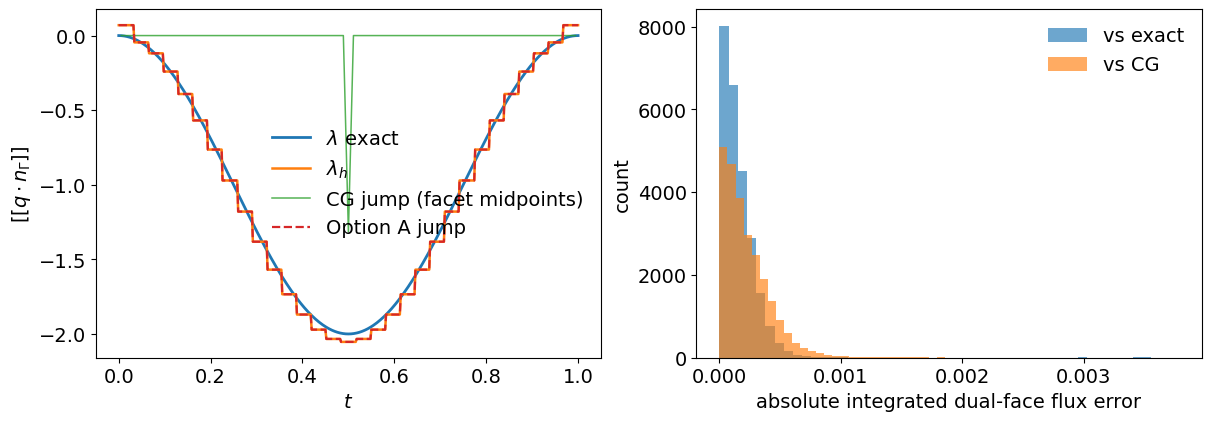

Option A analytic-trace jump check: PASS, max|jump-lambda_h|=0.000e+00
Option A completed: all construction gates passed before Option B.


In [11]:
hardcurl.plot_option_a_verification(problem, option_A)
option_A_audit = option_A["audit"]
print("Option A completed: all construction gates passed before Option B.")

# Option B — two subdomain stream functions

\(q_B^\pm=q_{p,f}+\nabla^\perp\psi_\pm\). No \(q_{p,\lambda}\) is used. The multiplier is imposed only through the difference constraint \((q_B^+-q_B^-)\cdot n_\Gamma=\lambda_h\); it is never split 50/50. Each cut data face contributes its one-sided segments. The corner-to-corner geometry has no artificial extension, so that term is reported as N/A.

## B1–B2. Penalty sweep and training

In [12]:
option_B = hardcurl.run_option_b(
    problem, penalty_weights=B_PENALTY_WEIGHTS,
    adam_steps=ADAM_STEPS_B, lbfgs_steps=LBFGS_STEPS_B,
    width=24, depth=2, lr=2.0e-3,
)

Option B penalty=1: two width=24, depth=2 networks, parameters=1970
  Adam     1/2000: loss=8.614677e+00
  Adam   250/2000: loss=9.175961e-02
  Adam   500/2000: loss=1.923401e-02
  Adam   750/2000: loss=1.735661e-02
  Adam  1000/2000: loss=8.543497e-03
  Adam  1250/2000: loss=6.863150e-03
  Adam  1500/2000: loss=6.146332e-03
  Adam  1750/2000: loss=5.439972e-03
  Adam  2000/2000: loss=4.667108e-03
  L-BFGS final: loss=2.921024e-03
Option B conservation audit, penalty=1
  RHS             class                    n       RMSE        max|R|
  lambda_h        interior-away            3782   4.846e-17   1.330e-15
  lambda_h        fracture-cut               63   5.318e-04   1.054e-03
  lambda_h        fracture-adjacent         124   4.702e-03   7.646e-03
  lambda_h        boundary                  256   3.981e-05   3.422e-04
  lambda_h        source                      0          N/A          N/A
  exact_lambda    interior-away            3782   4.846e-17   1.330e-15
  exact_lambda    frac

## B3. Verification battery and penalty floor

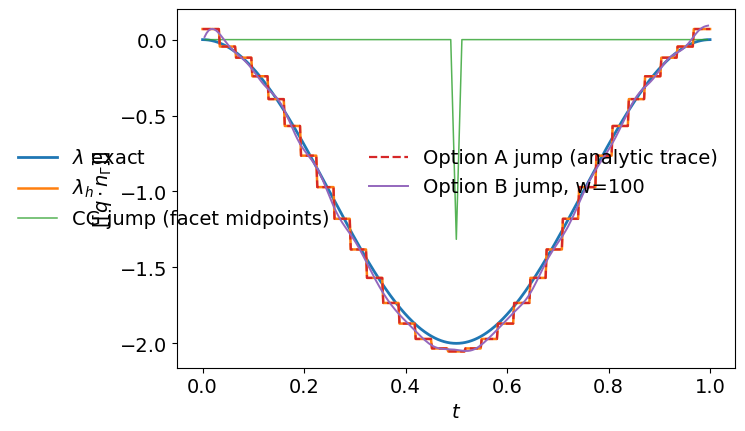

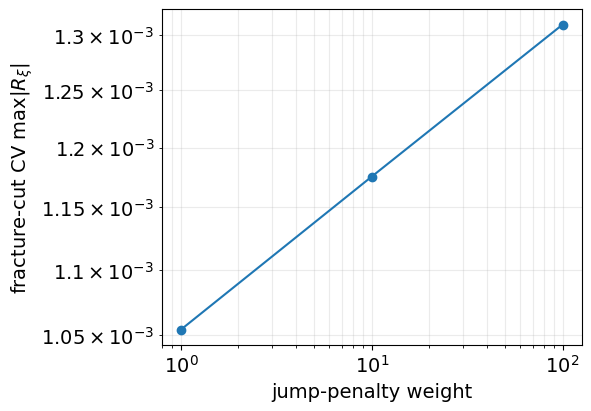

In [13]:
hardcurl.plot_verification(problem, option_A, option_B)

## Final A/B comparison

The table reports measured accuracy, conservation, parameter count, and wall time without ranking beyond the numerical evidence.

In [14]:
comparison_rows = hardcurl.comparison_table(problem, option_A, option_B)

Final Option A/B comparison
  option       flux RMSE exact   flux RMSE CG   jump RMSE lambda_h   worst class             max|R|      params    wall(s)
  A                 2.5766e-04     3.1504e-04         0.0000e+00 interior-away           6.692e-16      5665    150.77
  B(w=100)          5.7121e-03     5.7315e-03         4.4409e-02 fracture-adjacent       7.607e-03      1970    105.69


In [15]:
import json as _json
SUMMARY_DIR = pathlib.Path("result_fracture_MMS_hardcurl_AB")
SUMMARY_DIR.mkdir(exist_ok=True)
mesh_summary = {
    "mesh": VARIANT,
    "A_flux_error": comparison_rows[0]["face_flux_RMSE_exact"],
    "B_flux_error": comparison_rows[1]["face_flux_RMSE_exact"],
    "A_worst_Rxi": comparison_rows[0]["worst_Rxi"],
    "B_worst_Rxi": comparison_rows[1]["worst_Rxi"],
    "A_jump_error": comparison_rows[0]["jump_RMSE_lambda_h"],
    "B_jump_error": comparison_rows[1]["jump_RMSE_lambda_h"],
}
summary_file = SUMMARY_DIR / f"{VARIANT}_summary.json"
summary_file.write_text(_json.dumps(mesh_summary, indent=2) + "\n")
print("Saved", summary_file)

Saved result_fracture_MMS_hardcurl_AB/nonconforming_tri_summary.json


### Conclusion

Option A is conservative by construction with the discrete multiplier-consistent RHS: its line-source particular field carries the exchange distribution and its curl correction cannot change any closed-CV balance. Option B reaches only the penalty-controlled conservation floor shown above; its two smaller networks trade exact jump enforcement for a soft interface constraint. The measured flux errors, parameter counts, and wall times are reported in the table.